In [1]:
# Install necessary libraries
!pip install diffusers datasets transformers accelerate scipy ftfy

import datasets
import diffusers
import huggingface_hub
import torch
from diffusers import DDPMPipeline
from PIL import Image
from datasets import load_dataset
from torchvision import transforms
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
from torch.nn import functional as F
from matplotlib import pyplot as plt

# Suppress warnings
datasets.logging.set_verbosity_error()
diffusers.logging.set_verbosity_error()
huggingface_hub.logging.set_verbosity_error()

# Load your own dataset
dataset = load_dataset("mlnomad/imnet1k_ostrich_Struthio_camelus", split="train")  # Example dataset, replace with your dataset


# Create a subset of the first 1024 images
######## Changed dataset to 4096 images ########
dataset = dataset.select(range(1024))

# Check the length of the subset
print(f"Length of the subset: {len(dataset)}")

# Preprocessing
########  Double the resolution: image_size = 64 ########
image_size = 128
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform(examples):
    examples["pixel_values"] = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return examples

# Apply the transform to the dataset
dataset.set_transform(transform)

# Create a custom dataset class to return tensors directly
class TensorDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        return self.hf_dataset[idx]["pixel_values"]  # Return tensor directly

# Wrap the dataset in the custom class
tensor_dataset = TensorDataset(dataset)

# Create dataloader
# batch_size = 16 -> Change to 8 since resolution was increased 2x
batch_size = 8
train_dataloader = torch.utils.data.DataLoader(tensor_dataset, batch_size=batch_size, shuffle=True)

# Model and scheduler
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    ######## block_out_channels=(64, 128, 256, 512),  # Number of channels in each block
    ######## Increased capacity = More capacity to learn
    block_out_channels=(128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",     # Downsampling blocks
        "DownBlock2D",
        "AttnDownBlock2D", # Downsampling blocks with attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",   # Upsampling blocks with attention
        "AttnUpBlock2D",
        "UpBlock2D",       # Upsampling blocks
        "UpBlock2D"),
).to("cuda")

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# Optimizer -> Also changed this to have better learning rate
#optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Training loop
######## 10 -> 50 to have more training
######## Note: Changing the number of epochs means adjusting # of iterations
######## the model will work through the full dataset to learn patterns
num_epochs = 50

for epoch in range(num_epochs):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch.to("cuda")  # Move batch to GPU
        noise = torch.randn(clean_images.shape).to("cuda")
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (batch_size,), device="cuda").long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f"Epoch {epoch}, Step {step}: Loss = {loss.item()}")

# Save the model
# Replace with your desired path
torch.save(model.state_dict(), "animal_diffusion_model.pth")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/7.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1300 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50 [00:00<?, ? examples/s]

Length of the subset: 1024
Epoch 0, Step 0: Loss = 1.1708471775054932
Epoch 0, Step 100: Loss = 0.07412630319595337
Epoch 1, Step 0: Loss = 0.03351737558841705
Epoch 1, Step 100: Loss = 0.050610415637493134
Epoch 2, Step 0: Loss = 0.02166995406150818
Epoch 2, Step 100: Loss = 0.029766133055090904
Epoch 3, Step 0: Loss = 0.03767848759889603
Epoch 3, Step 100: Loss = 0.03719793260097504
Epoch 4, Step 0: Loss = 0.014655254781246185
Epoch 4, Step 100: Loss = 0.030916957184672356
Epoch 5, Step 0: Loss = 0.03562271595001221
Epoch 5, Step 100: Loss = 0.016198601573705673
Epoch 6, Step 0: Loss = 0.0912897139787674
Epoch 6, Step 100: Loss = 0.014642762020230293
Epoch 7, Step 0: Loss = 0.06193813681602478
Epoch 7, Step 100: Loss = 0.1259756088256836
Epoch 8, Step 0: Loss = 0.01226708572357893
Epoch 8, Step 100: Loss = 0.06600605696439743
Epoch 9, Step 0: Loss = 0.0046957191079854965
Epoch 9, Step 100: Loss = 0.007036722265183926
Epoch 10, Step 0: Loss = 0.012578209862112999
Epoch 10, Step 100: L

Length of the dataset: 1024


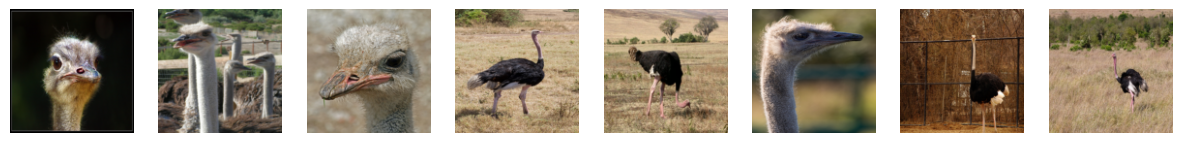

In [2]:
# Check the length of the dataset
print(f"Length of the dataset: {len(dataset)}")

# Visualize some images from the dataset
import matplotlib.pyplot as plt

def visualize_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        # Get an image from the dataset
        image = dataset[i]["pixel_values"]  # Access the preprocessed tensor
        # Convert tensor to numpy and denormalize
        image = image.permute(1, 2, 0).cpu().numpy()  # Change from (C, H, W) to (H, W, C)
        image = (image * 0.5) + 0.5  # Denormalize from [-1, 1] to [0, 1]
        axes[i].imshow(image)
        axes[i].axis("off")
    plt.show()

# Visualize 5 images
visualize_images(dataset, num_images=8)

## Generate images from the trained model

In [16]:
import torch
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
import matplotlib.pyplot as plt
import os
import gc

# Clear GPU memory first
torch.cuda.empty_cache()
gc.collect()

# Load the trained model
model = UNet2DModel(
    sample_size=128,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"),
).to("cuda")

model.load_state_dict(torch.load("animal_diffusion_model.pth"))
model.eval()

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise_scheduler.set_timesteps(100)

def generate_images(num_images=1, batch_size=2):
    all_images = []

    with torch.no_grad():
        for batch_idx in range(0, num_images, batch_size):
            batch_count = min(batch_size, num_images - batch_idx)

            noise = torch.randn((batch_count, 3, 128, 128)).to("cuda")
            images = noise

            for t in noise_scheduler.timesteps:
                noise_pred = model(images, t).sample
                images = noise_scheduler.step(noise_pred, t, images).prev_sample

            images = images.detach().cpu()
            images = (images * 0.5) + 0.5
            images = torch.clamp(images, 0, 1)

            all_images.append(images)

            # Aggressively clear memory
            del noise, images
            torch.cuda.empty_cache()

    return torch.cat(all_images, dim=0)

# Generate 50 images
num_images = 50
generated_images = generate_images(num_images, batch_size=2)

# Save images
os.makedirs("images", exist_ok=True)

for i, img in enumerate(generated_images):
    img = img.permute(1, 2, 0)
    filename = f"images/animal_{i:02d}.png"
    plt.imsave(filename, img.numpy())

# Create grid
fig, axes = plt.subplots(5, 10, figsize=(25, 12))
axes = axes.flatten()
for i, img in enumerate(generated_images):
    img = img.permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("images/animal_grid.png", dpi=150, bbox_inches='tight')
plt.close()

# Create zip
import shutil
shutil.make_archive("animals", "zip", "images")

# Clean up
del model, generated_images
torch.cuda.empty_cache()
gc.collect()

11512

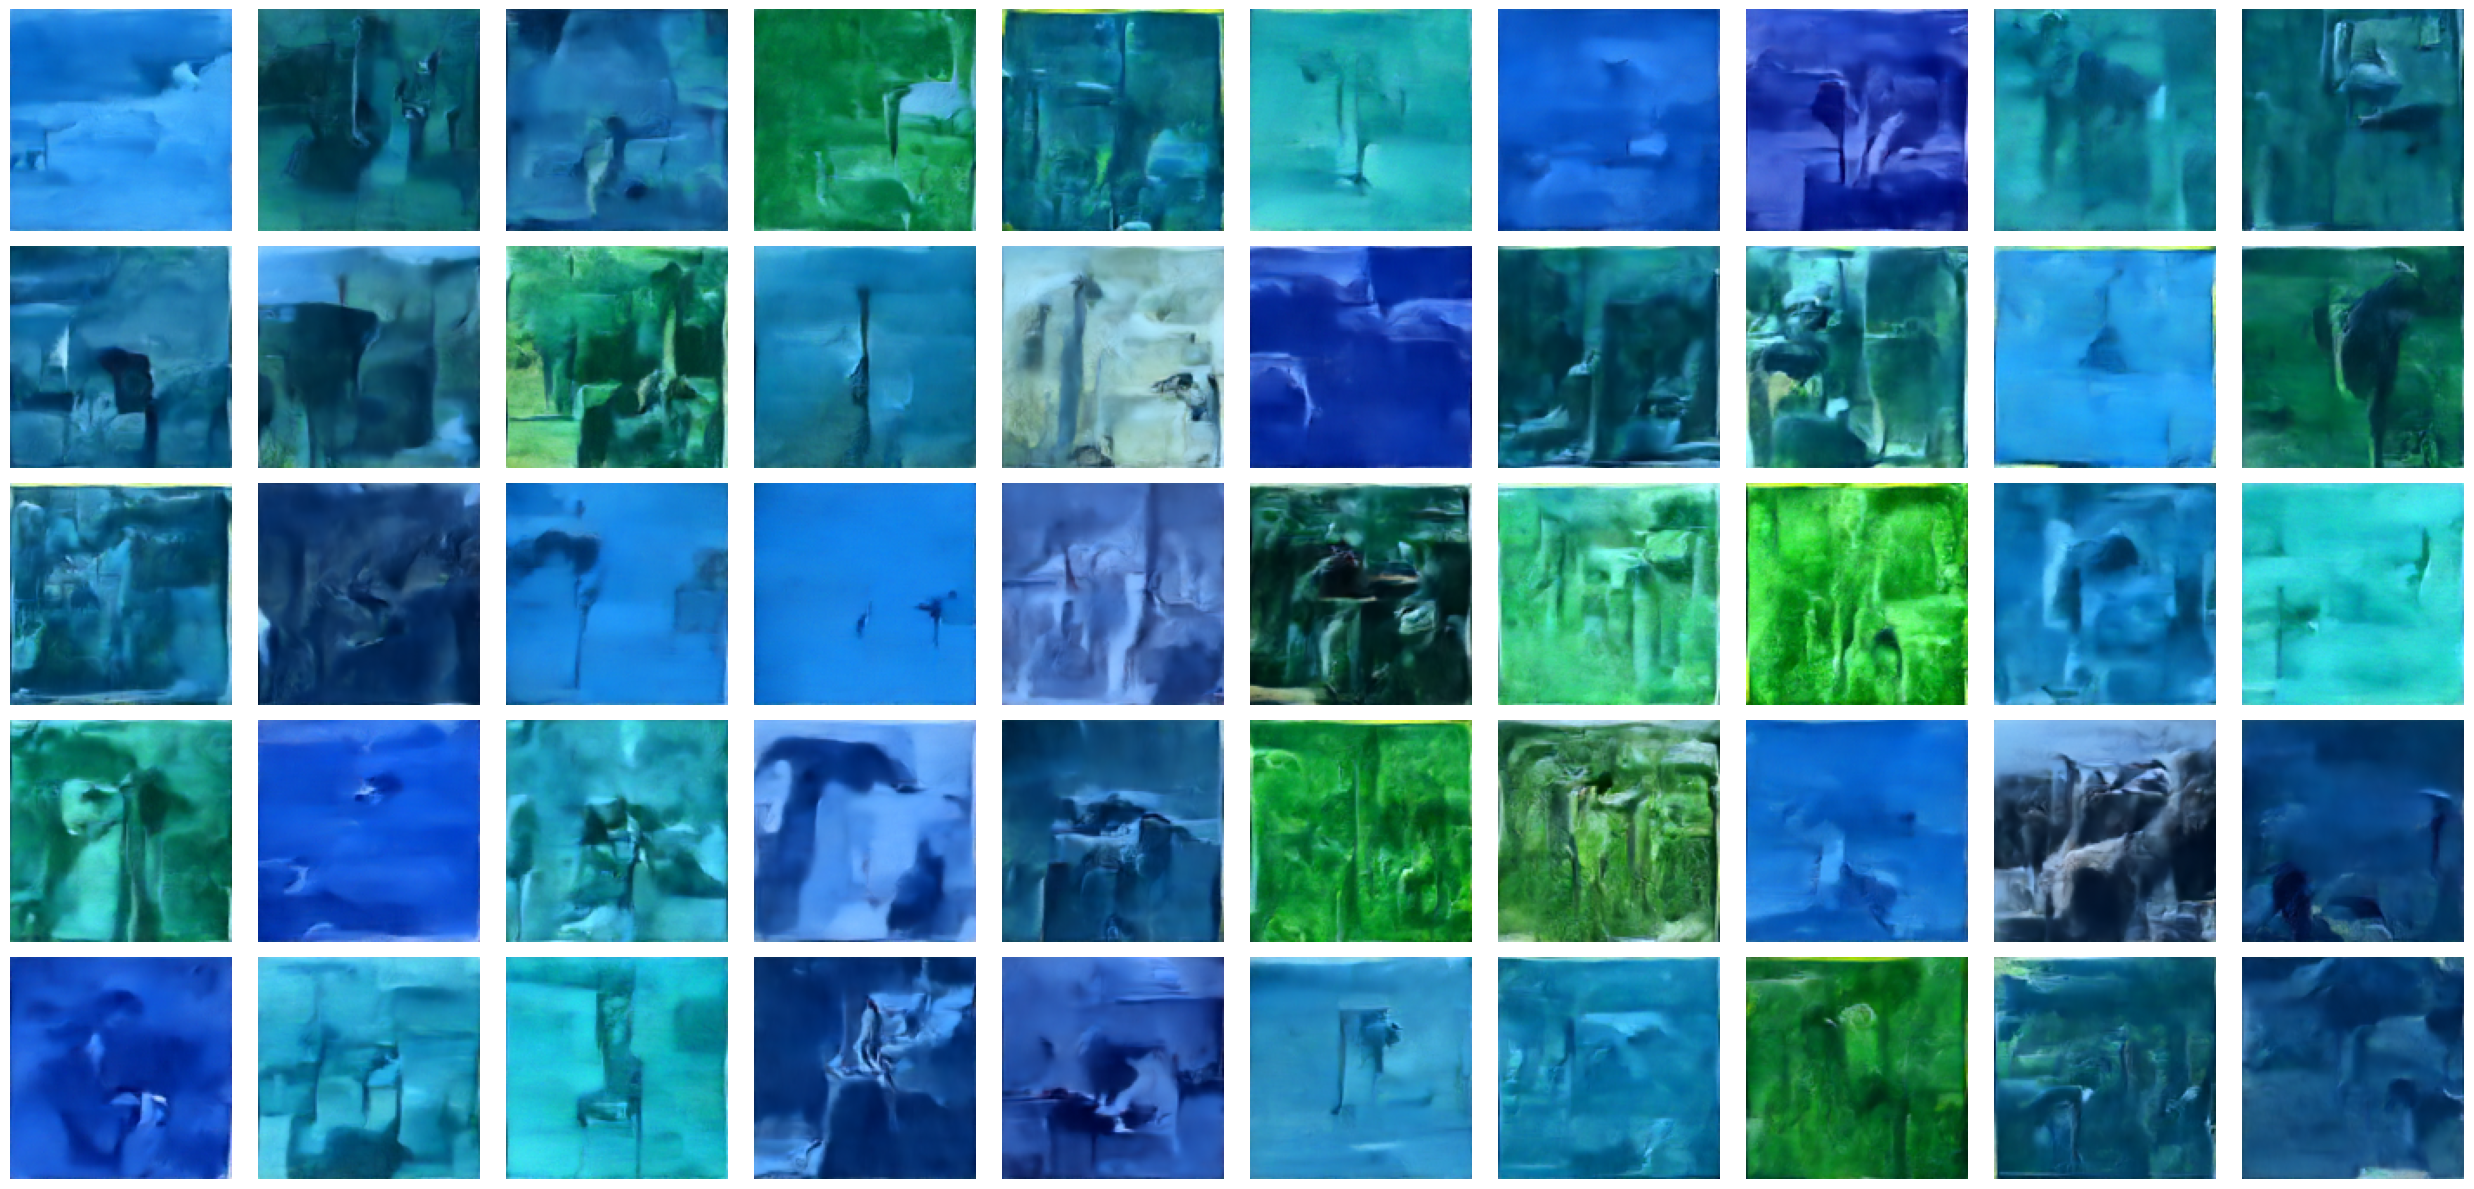

97755

In [18]:
import torch
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
import matplotlib.pyplot as plt
import os
import gc

######## Clear GPU memory first
torch.cuda.empty_cache()
gc.collect()

######## LOAD MODEL
model = UNet2DModel(
    sample_size=128,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"),
).to("cuda")

model.load_state_dict(torch.load("animal_diffusion_model.pth"))
model.eval()

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise_scheduler.set_timesteps(100)

######## GENERATE IMAGES
def generate_images(num_images=1, batch_size=2):
    all_images = []

    with torch.no_grad():
        for batch_idx in range(0, num_images, batch_size):
            batch_count = min(batch_size, num_images - batch_idx)

            noise = torch.randn((batch_count, 3, 128, 128)).to("cuda")
            images = noise

            for t in noise_scheduler.timesteps:
                noise_pred = model(images, t).sample
                images = noise_scheduler.step(noise_pred, t, images).prev_sample

            images = images.detach().cpu()
            images = (images * 0.5) + 0.5
            images = torch.clamp(images, 0, 1)

            all_images.append(images)

            del noise, images
            torch.cuda.empty_cache()

    return torch.cat(all_images, dim=0)

num_images = 50
generated_images = generate_images(num_images, batch_size=2)

######## SAVE IMAGES
os.makedirs("images", exist_ok=True)

for i, img in enumerate(generated_images):
    img = img.permute(1, 2, 0)
    filename = f"images/animal_{i:02d}.png"
    plt.imsave(filename, img.numpy())

######## CREATE GRID
fig, axes = plt.subplots(5, 10, figsize=(25, 12))
axes = axes.flatten()
for i, img in enumerate(generated_images):
    img = img.permute(1, 2, 0)
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("images/animal_grid.png", dpi=150, bbox_inches='tight')
plt.show()

######## CREATE ZIP
import shutil
shutil.make_archive("animals", "zip", "images")

######## Clean up
del model, generated_images
torch.cuda.empty_cache()
gc.collect()

In [19]:
# !rm -rf images/

# Utility to zip a file
import shutil
shutil.make_archive("animals", "zip", "images")

'/content/animals.zip'

In [20]:
from google.colab import files
files.download('animals.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>